# 🎰 Análise Comparativa de Métodos de Aposta na Mega-Sena

## Objetivo
Comparar 4 estratégias de aposta:

1. 🔥 **Top 6** - Apostar nos 6 números mais frequentes
2. ❄️ **Bottom 6** - Apostar nos 6 números menos frequentes
3. 🔄 **Misto** - 3 mais frequentes + 3 menos frequentes
4. 🎲 **Aleatório** - Baseline para comparação

## Metodologia
- Calculamos frequências acumuladas até cada concurso
- Usamos essas frequências para fazer "apostas" no próximo sorteio
- Verificamos quantos acertos cada estratégia obteve
- Comparamos com a expectativa teórica aleatória

In [1]:
# ============================================================================
# IMPORTS E CONFIGURAÇÕES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Constantes
TOTAL_NUMBERS = 60
NUMBERS_DRAWN = 6
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("✅ Bibliotecas carregadas com sucesso!")
print(f"   Total de números: {TOTAL_NUMBERS}")
print(f"   Números sorteados por jogo: {NUMBERS_DRAWN}")

✅ Bibliotecas carregadas com sucesso!
   Total de números: 60
   Números sorteados por jogo: 6


---
## 1. 📥 Carregamento dos Dados

In [2]:
# Carregar dados
df = pd.read_excel('Mega-Sena.xlsx')

# Identificar colunas de bolas
ball_columns = ['Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6']
data_balls = df[ball_columns].dropna().astype(int).values

# Ordenar cada sorteio
sorteios = np.sort(data_balls, axis=1)

print(f"✅ Dados carregados com sucesso!")
print(f"   Total de concursos: {len(sorteios):,}")
print(f"   Período: Concurso 1 a {len(sorteios)}")
print(f"\n📊 Amostra dos primeiros sorteios:")
for i in range(5):
    print(f"   Concurso {i+1}: {sorteios[i]}")

✅ Dados carregados com sucesso!
   Total de concursos: 2,949
   Período: Concurso 1 a 2949

📊 Amostra dos primeiros sorteios:
   Concurso 1: [ 4  5 30 33 41 52]
   Concurso 2: [ 9 37 39 41 43 49]
   Concurso 3: [10 11 29 30 36 47]
   Concurso 4: [ 1  5  6 27 42 59]
   Concurso 5: [ 1  2  6 16 19 46]


---
## 2. 📊 Análise de Frequência Global

In [3]:
# Calculando frequência total de cada número
all_numbers = sorteios.flatten()
frequency_counter = Counter(all_numbers)

# Criar array de frequências (índice 0 = número 1)
frequencies = np.array([frequency_counter.get(i, 0) for i in range(1, TOTAL_NUMBERS + 1)])

# Top 6 e Bottom 6 globais
sorted_indices = np.argsort(frequencies)
bottom6_global = sorted_indices[:6] + 1  # +1 porque números vão de 1-60
top6_global = sorted_indices[-6:][::-1] + 1

print("="*60)
print("📊 FREQUÊNCIA GLOBAL DOS NÚMEROS")
print("="*60)
print(f"\n🔥 Top 6 mais frequentes:")
for num in top6_global:
    print(f"   Número {num:2d}: {frequencies[num-1]:3d} vezes ({frequencies[num-1]/len(sorteios)*100:.1f}%)")

print(f"\n❄️ Bottom 6 menos frequentes:")
for num in bottom6_global:
    print(f"   Número {num:2d}: {frequencies[num-1]:3d} vezes ({frequencies[num-1]/len(sorteios)*100:.1f}%)")

# Média teórica
expected_freq = len(sorteios) * NUMBERS_DRAWN / TOTAL_NUMBERS
print(f"\n📈 Frequência esperada (teórica): {expected_freq:.1f} vezes por número")

📊 FREQUÊNCIA GLOBAL DOS NÚMEROS

🔥 Top 6 mais frequentes:
   Número 10: 344 vezes (11.7%)
   Número 53: 336 vezes (11.4%)
   Número  5: 320 vezes (10.9%)
   Número 34: 320 vezes (10.9%)
   Número 37: 319 vezes (10.8%)
   Número 33: 316 vezes (10.7%)

❄️ Bottom 6 menos frequentes:
   Número 26: 243 vezes (8.2%)
   Número 21: 245 vezes (8.3%)
   Número 55: 255 vezes (8.6%)
   Número 22: 263 vezes (8.9%)
   Número 15: 264 vezes (9.0%)
   Número  3: 273 vezes (9.3%)

📈 Frequência esperada (teórica): 294.9 vezes por número


---
## 3. 🎯 Definição das Estratégias de Aposta

In [4]:
def calcular_frequencias_acumuladas(sorteios_ate_idx):
    """
    Calcula a frequência de cada número até um determinado índice.
    """
    if len(sorteios_ate_idx) == 0:
        return np.zeros(TOTAL_NUMBERS)
    
    all_nums = sorteios_ate_idx.flatten()
    counter = Counter(all_nums)
    freqs = np.array([counter.get(i, 0) for i in range(1, TOTAL_NUMBERS + 1)])
    return freqs


def estrategia_top6(frequencies):
    """Retorna os 6 números mais frequentes."""
    sorted_indices = np.argsort(frequencies)
    return sorted(sorted_indices[-6:] + 1)  # +1 para números 1-60


def estrategia_bottom6(frequencies):
    """Retorna os 6 números menos frequentes."""
    sorted_indices = np.argsort(frequencies)
    return sorted(sorted_indices[:6] + 1)


def estrategia_mista(frequencies):
    """
    Retorna 3 mais frequentes + 3 menos frequentes.
    """
    sorted_indices = np.argsort(frequencies)
    bottom3 = sorted_indices[:3] + 1
    top3 = sorted_indices[-3:] + 1
    return sorted(list(bottom3) + list(top3))


def estrategia_aleatoria():
    """Retorna 6 números aleatórios."""
    return sorted(np.random.choice(range(1, TOTAL_NUMBERS + 1), NUMBERS_DRAWN, replace=False))


def contar_acertos(aposta, sorteio):
    """Conta quantos números da aposta estão no sorteio."""
    return len(set(aposta) & set(sorteio))


print("✅ Funções de estratégia definidas!")
print("\n📋 Estratégias disponíveis:")
print("   1. Top 6 - Aposta nos 6 mais frequentes")
print("   2. Bottom 6 - Aposta nos 6 menos frequentes")
print("   3. Mista - 3 mais + 3 menos frequentes")
print("   4. Aleatória - 6 números aleatórios")

✅ Funções de estratégia definidas!

📋 Estratégias disponíveis:
   1. Top 6 - Aposta nos 6 mais frequentes
   2. Bottom 6 - Aposta nos 6 menos frequentes
   3. Mista - 3 mais + 3 menos frequentes
   4. Aleatória - 6 números aleatórios


---
## 4. 🔬 Simulação das Estratégias

Para cada concurso (a partir do 100º para ter histórico suficiente):
1. Calculamos as frequências de todos os sorteios anteriores
2. Fazemos a aposta de acordo com cada estratégia
3. Verificamos quantos acertos em relação ao próximo sorteio

In [5]:
# Parâmetros da simulação
START_IDX = 100  # Começar após ter histórico suficiente
N_SIMULATIONS = len(sorteios) - START_IDX

print(f"⏳ Iniciando simulação de {N_SIMULATIONS:,} apostas...")
print(f"   Período: Concurso {START_IDX + 1} a {len(sorteios)}")

# Armazenar resultados
resultados = {
    'top6': [],
    'bottom6': [],
    'mista': [],
    'aleatoria': []
}

# Histórico de apostas (para análise detalhada)
apostas_detalhadas = {
    'top6': [],
    'bottom6': [],
    'mista': [],
    'aleatoria': []
}

# Simular para cada concurso
for i in range(START_IDX, len(sorteios)):
    # Frequências até o concurso anterior
    freq_atual = calcular_frequencias_acumuladas(sorteios[:i])
    
    # Fazer apostas
    aposta_top6 = estrategia_top6(freq_atual)
    aposta_bottom6 = estrategia_bottom6(freq_atual)
    aposta_mista = estrategia_mista(freq_atual)
    aposta_aleatoria = estrategia_aleatoria()
    
    # Sorteio real
    sorteio_real = sorteios[i]
    
    # Contar acertos
    acertos_top6 = contar_acertos(aposta_top6, sorteio_real)
    acertos_bottom6 = contar_acertos(aposta_bottom6, sorteio_real)
    acertos_mista = contar_acertos(aposta_mista, sorteio_real)
    acertos_aleatoria = contar_acertos(aposta_aleatoria, sorteio_real)
    
    # Armazenar resultados
    resultados['top6'].append(acertos_top6)
    resultados['bottom6'].append(acertos_bottom6)
    resultados['mista'].append(acertos_mista)
    resultados['aleatoria'].append(acertos_aleatoria)
    
    # Armazenar apostas detalhadas
    apostas_detalhadas['top6'].append(aposta_top6)
    apostas_detalhadas['bottom6'].append(aposta_bottom6)
    apostas_detalhadas['mista'].append(aposta_mista)
    apostas_detalhadas['aleatoria'].append(aposta_aleatoria)
    
    # Progresso
    if (i - START_IDX + 1) % 500 == 0:
        print(f"   Processados: {i - START_IDX + 1:,} concursos")

print(f"\n✅ Simulação concluída!")
print(f"   Total de apostas simuladas: {N_SIMULATIONS:,}")

⏳ Iniciando simulação de 2,849 apostas...
   Período: Concurso 101 a 2949
   Processados: 500 concursos
   Processados: 1,000 concursos
   Processados: 1,500 concursos
   Processados: 2,000 concursos
   Processados: 2,500 concursos

✅ Simulação concluída!
   Total de apostas simuladas: 2,849


---
## 5. 📈 Análise dos Resultados

In [6]:
# Converter para arrays numpy
for key in resultados:
    resultados[key] = np.array(resultados[key])

# Estatísticas gerais
print("="*70)
print("📊 ESTATÍSTICAS GERAIS DOS ACERTOS")
print("="*70)

estrategias = ['top6', 'bottom6', 'mista', 'aleatoria']
nomes = ['🔥 Top 6', '❄️ Bottom 6', '🔄 Mista', '🎲 Aleatória']

stats_resumo = {}

for est, nome in zip(estrategias, nomes):
    acertos = resultados[est]
    stats_resumo[est] = {
        'media': np.mean(acertos),
        'mediana': np.median(acertos),
        'std': np.std(acertos),
        'max': np.max(acertos),
        'total': np.sum(acertos)
    }
    
    print(f"\n{nome}:")
    print(f"   Média de acertos: {stats_resumo[est]['media']:.3f}")
    print(f"   Mediana: {stats_resumo[est]['mediana']:.1f}")
    print(f"   Desvio padrão: {stats_resumo[est]['std']:.3f}")
    print(f"   Máximo de acertos: {stats_resumo[est]['max']}")
    print(f"   Total de acertos: {stats_resumo[est]['total']:,}")

📊 ESTATÍSTICAS GERAIS DOS ACERTOS

🔥 Top 6:
   Média de acertos: 0.602
   Mediana: 0.0
   Desvio padrão: 0.697
   Máximo de acertos: 4
   Total de acertos: 1,715

❄️ Bottom 6:
   Média de acertos: 0.568
   Mediana: 0.0
   Desvio padrão: 0.685
   Máximo de acertos: 3
   Total de acertos: 1,618

🔄 Mista:
   Média de acertos: 0.582
   Mediana: 0.0
   Desvio padrão: 0.695
   Máximo de acertos: 4
   Total de acertos: 1,659

🎲 Aleatória:
   Média de acertos: 0.610
   Mediana: 0.0
   Desvio padrão: 0.712
   Máximo de acertos: 4
   Total de acertos: 1,737


In [7]:
# Distribuição de acertos por estratégia
print("\n" + "="*70)
print("📊 DISTRIBUIÇÃO DE ACERTOS POR ESTRATÉGIA")
print("="*70)

distribuicao = {}

for est, nome in zip(estrategias, nomes):
    acertos = resultados[est]
    contagem = {}
    for n_acertos in range(7):
        count = np.sum(acertos == n_acertos)
        perc = count / len(acertos) * 100
        contagem[n_acertos] = {'count': count, 'perc': perc}
    distribuicao[est] = contagem
    
    print(f"\n{nome}:")
    for n_acertos in range(7):
        c = contagem[n_acertos]['count']
        p = contagem[n_acertos]['perc']
        bar = '█' * int(p/2)
        print(f"   {n_acertos} acertos: {c:5d} ({p:5.2f}%) {bar}")


📊 DISTRIBUIÇÃO DE ACERTOS POR ESTRATÉGIA

🔥 Top 6:
   0 acertos:  1454 (51.04%) █████████████████████████
   1 acertos:  1105 (38.79%) ███████████████████
   2 acertos:   261 ( 9.16%) ████
   3 acertos:    28 ( 0.98%) 
   4 acertos:     1 ( 0.04%) 
   5 acertos:     0 ( 0.00%) 
   6 acertos:     0 ( 0.00%) 

❄️ Bottom 6:
   0 acertos:  1526 (53.56%) ██████████████████████████
   1 acertos:  1051 (36.89%) ██████████████████
   2 acertos:   249 ( 8.74%) ████
   3 acertos:    23 ( 0.81%) 
   4 acertos:     0 ( 0.00%) 
   5 acertos:     0 ( 0.00%) 
   6 acertos:     0 ( 0.00%) 

🔄 Mista:
   0 acertos:  1502 (52.72%) ██████████████████████████
   1 acertos:  1063 (37.31%) ██████████████████
   2 acertos:   258 ( 9.06%) ████
   3 acertos:    24 ( 0.84%) 
   4 acertos:     2 ( 0.07%) 
   5 acertos:     0 ( 0.00%) 
   6 acertos:     0 ( 0.00%) 

🎲 Aleatória:
   0 acertos:  1466 (51.46%) █████████████████████████
   1 acertos:  1058 (37.14%) ██████████████████
   2 acertos:   297 (10.42%) ████

---
## 6. 📐 Probabilidade Teórica (Distribuição Hipergeométrica)

In [8]:
from scipy.stats import hypergeom

# Parâmetros da Mega-Sena
# M = população total (60 números)
# n = números sorteados (6)
# N = números apostados (6)

M = TOTAL_NUMBERS  # 60
n = NUMBERS_DRAWN  # 6
N = NUMBERS_DRAWN  # 6

print("="*70)
print("📐 PROBABILIDADES TEÓRICAS (DISTRIBUIÇÃO HIPERGEOMÉTRICA)")
print("="*70)
print(f"\nParâmetros: População={M}, Sorteados={n}, Apostados={N}")

prob_teorica = {}
print("\n🎲 Probabilidades teóricas para aposta aleatória:")

for k in range(7):
    prob = hypergeom.pmf(k, M, n, N)
    prob_teorica[k] = prob
    odds = 1/prob if prob > 0 else float('inf')
    bar = '█' * int(prob * 100)
    print(f"   {k} acertos: {prob*100:7.4f}% (1 em {odds:,.0f}) {bar}")

# Valor esperado teórico
expected_value = hypergeom.mean(M, n, N)
theoretical_std = hypergeom.std(M, n, N)

print(f"\n📈 Valor esperado teórico: {expected_value:.4f} acertos")
print(f"   Desvio padrão teórico: {theoretical_std:.4f}")

📐 PROBABILIDADES TEÓRICAS (DISTRIBUIÇÃO HIPERGEOMÉTRICA)

Parâmetros: População=60, Sorteados=6, Apostados=6

🎲 Probabilidades teóricas para aposta aleatória:
   0 acertos: 51.5884% (1 em 2) ███████████████████████████████████████████████████
   1 acertos: 37.9017% (1 em 3) █████████████████████████████████████
   2 acertos:  9.4754% (1 em 11) █████████
   3 acertos:  0.9909% (1 em 101) 
   4 acertos:  0.0429% (1 em 2,332) 
   5 acertos:  0.0006% (1 em 154,518) 
   6 acertos:  0.0000% (1 em 50,063,860) 

📈 Valor esperado teórico: 0.6000 acertos
   Desvio padrão teórico: 0.7030


---
## 7. 📊 Comparação com Aleatoriedade

In [9]:
print("="*70)
print("📊 COMPARAÇÃO COM ALEATORIEDADE")
print("="*70)

# Calcular distância da aleatoriedade
distancia_aleatoriedade = {}

for est, nome in zip(estrategias, nomes):
    media = stats_resumo[est]['media']
    diff = media - expected_value
    diff_perc = (diff / expected_value) * 100
    distancia_aleatoriedade[est] = {
        'diff': diff,
        'diff_perc': diff_perc
    }
    
    if diff > 0:
        status = "📈 ACIMA"
    elif diff < 0:
        status = "📉 ABAIXO"
    else:
        status = "⚖️ IGUAL"
    
    print(f"\n{nome}:")
    print(f"   Média observada: {media:.4f}")
    print(f"   Média teórica:   {expected_value:.4f}")
    print(f"   Diferença:       {diff:+.4f} acertos ({diff_perc:+.2f}%)")
    print(f"   Status:          {status} da aleatoriedade")

📊 COMPARAÇÃO COM ALEATORIEDADE

🔥 Top 6:
   Média observada: 0.6020
   Média teórica:   0.6000
   Diferença:       +0.0020 acertos (+0.33%)
   Status:          📈 ACIMA da aleatoriedade

❄️ Bottom 6:
   Média observada: 0.5679
   Média teórica:   0.6000
   Diferença:       -0.0321 acertos (-5.35%)
   Status:          📉 ABAIXO da aleatoriedade

🔄 Mista:
   Média observada: 0.5823
   Média teórica:   0.6000
   Diferença:       -0.0177 acertos (-2.95%)
   Status:          📉 ABAIXO da aleatoriedade

🎲 Aleatória:
   Média observada: 0.6097
   Média teórica:   0.6000
   Diferença:       +0.0097 acertos (+1.61%)
   Status:          📈 ACIMA da aleatoriedade


In [10]:
# Teste estatístico de significância
print("\n" + "="*70)
print("📊 TESTES ESTATÍSTICOS (vs. Estratégia Aleatória)")
print("="*70)

for est, nome in zip(['top6', 'bottom6', 'mista'], ['🔥 Top 6', '❄️ Bottom 6', '🔄 Mista']):
    # Teste t de Student
    t_stat, p_value = stats.ttest_ind(resultados[est], resultados['aleatoria'])
    
    if p_value < 0.05:
        sig = "✅ SIGNIFICATIVO"
    else:
        sig = "❌ NÃO SIGNIFICATIVO"
    
    print(f"\n{nome} vs. Aleatória:")
    print(f"   Estatística t: {t_stat:.4f}")
    print(f"   p-valor: {p_value:.6f}")
    print(f"   Resultado: {sig} (α = 0.05)")


📊 TESTES ESTATÍSTICOS (vs. Estratégia Aleatória)

🔥 Top 6 vs. Aleatória:
   Estatística t: -0.4134
   p-valor: 0.679304
   Resultado: ❌ NÃO SIGNIFICATIVO (α = 0.05)

❄️ Bottom 6 vs. Aleatória:
   Estatística t: -2.2561
   p-valor: 0.024100
   Resultado: ✅ SIGNIFICATIVO (α = 0.05)

🔄 Mista vs. Aleatória:
   Estatística t: -1.4678
   p-valor: 0.142212
   Resultado: ❌ NÃO SIGNIFICATIVO (α = 0.05)


---
## 8. 📊 Visualizações Detalhadas

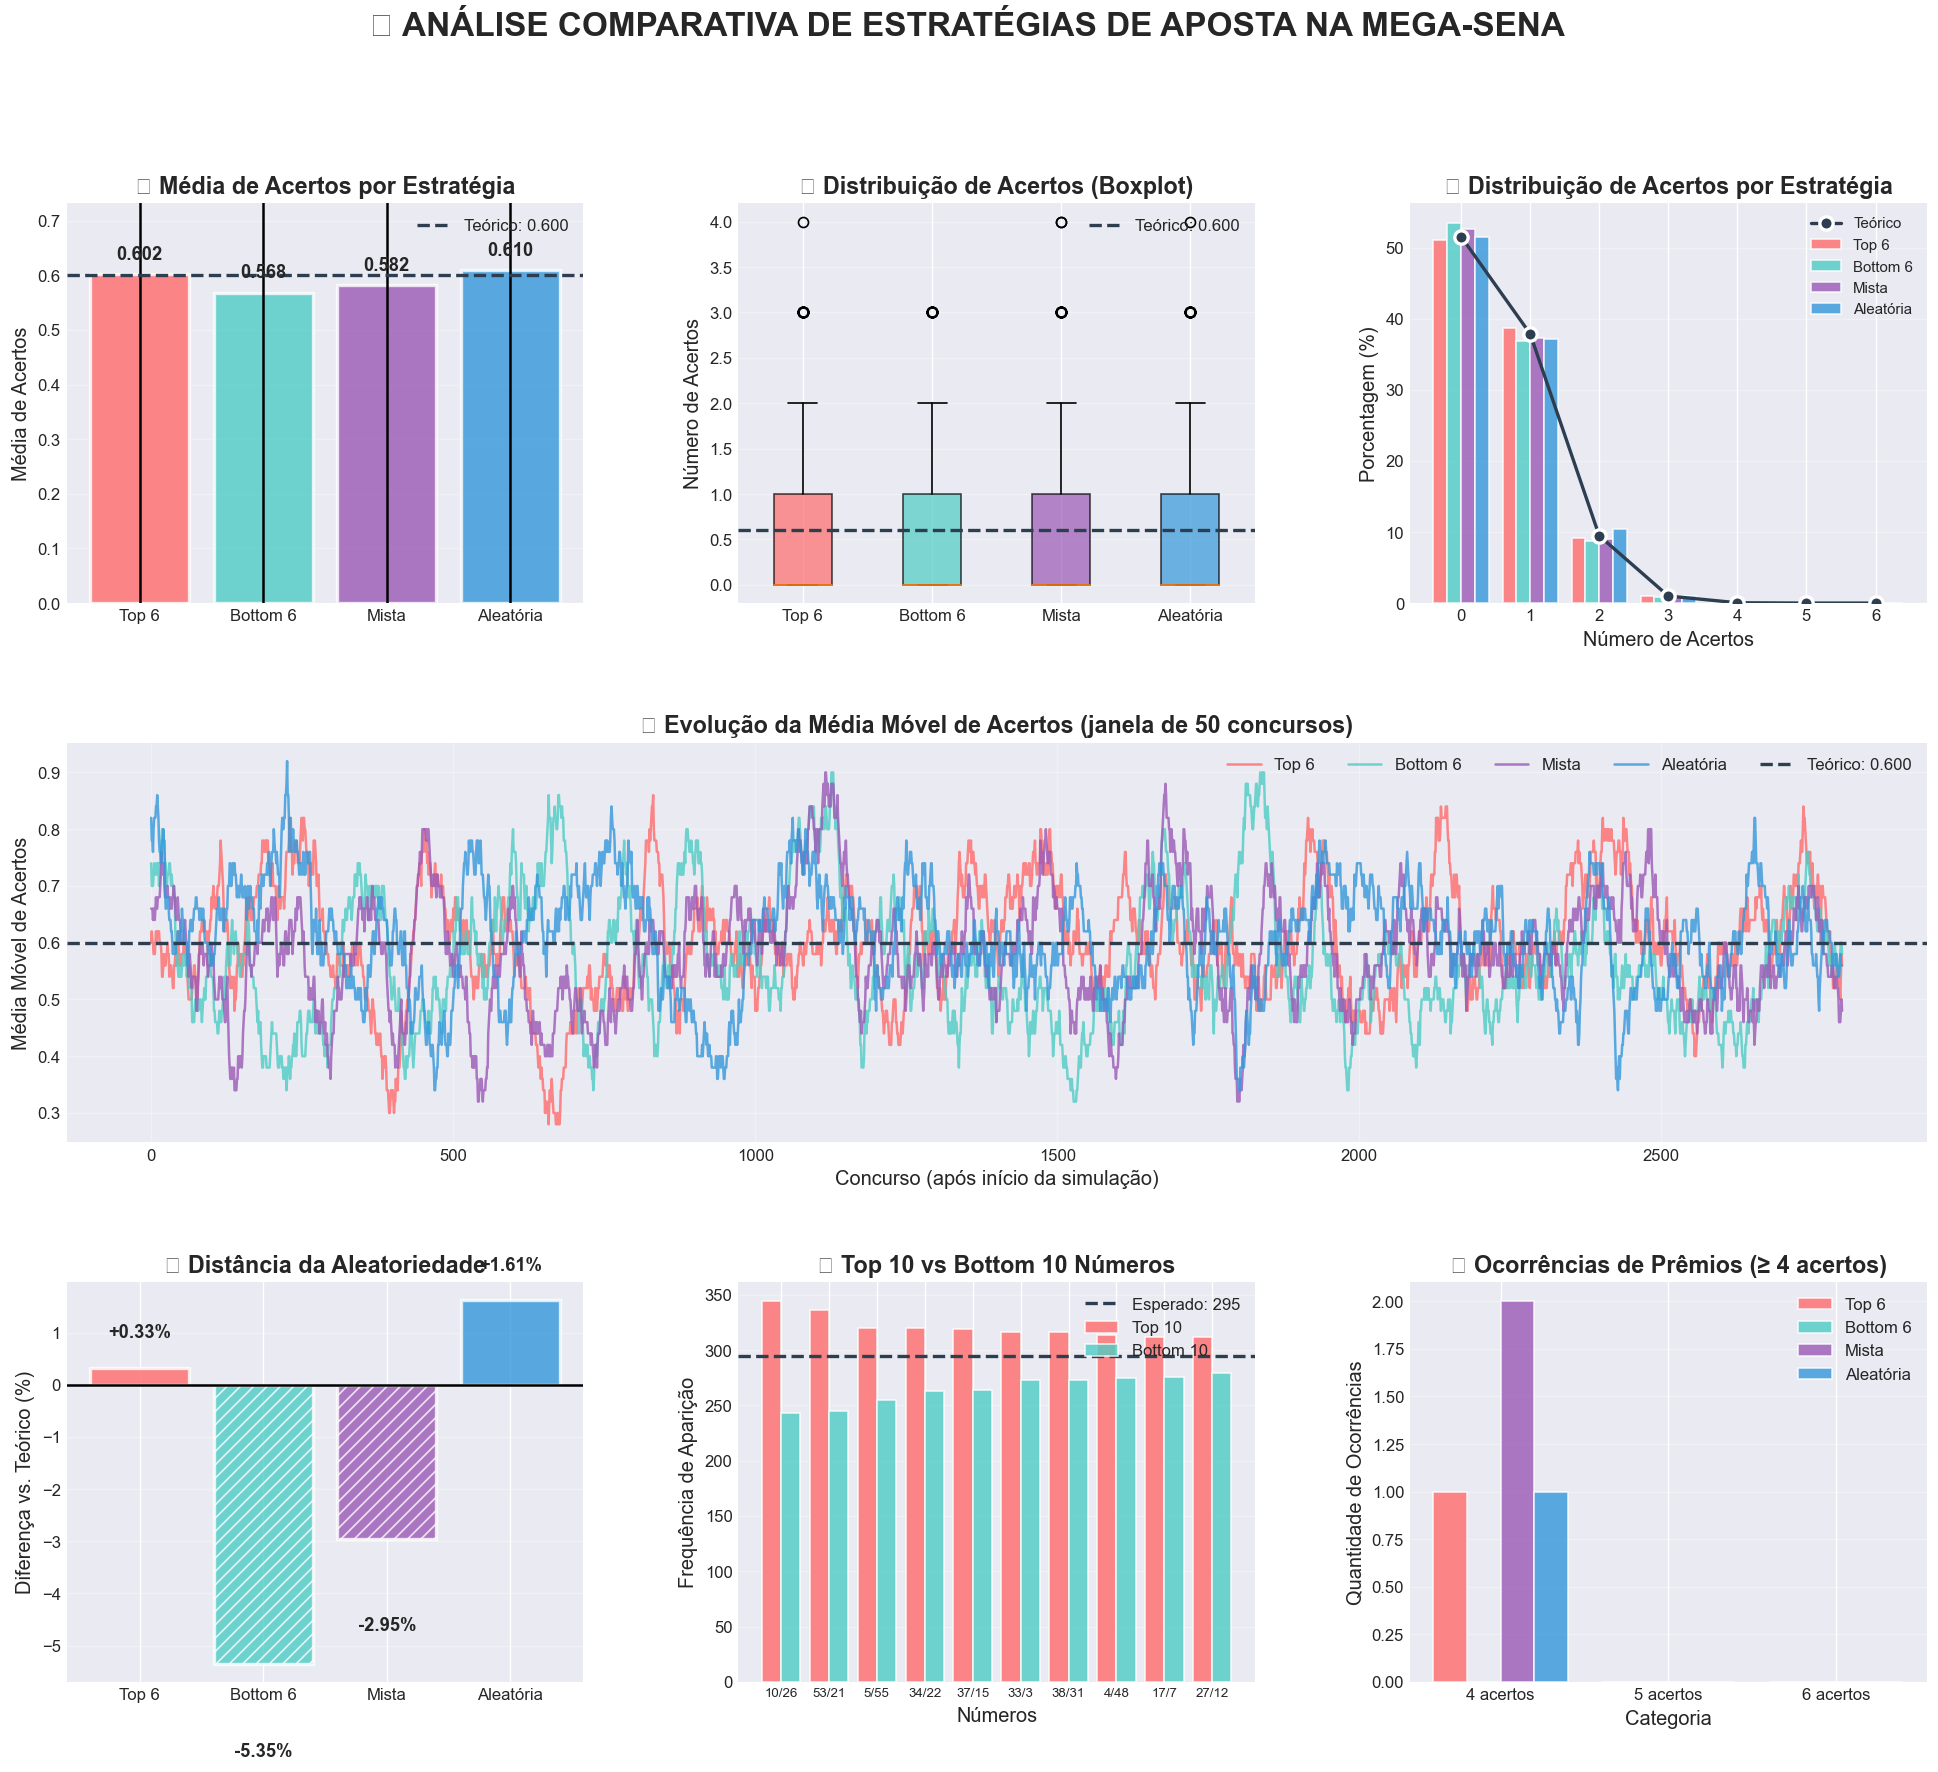


✅ Gráfico salvo como 'analise_comparativa_megasena.png'


In [11]:
# =============================================================================
# GRÁFICO PRINCIPAL - DASHBOARD COMPLETO
# =============================================================================

# Cores modernas
cores = {
    'top6': '#FF6B6B',      # Vermelho coral
    'bottom6': '#4ECDC4',   # Turquesa
    'mista': '#9B59B6',     # Roxo
    'aleatoria': '#3498DB', # Azul
    'teorica': '#2C3E50'    # Cinza escuro
}

fig = plt.figure(figsize=(20, 16))
fig.suptitle('🎰 ANÁLISE COMPARATIVA DE ESTRATÉGIAS DE APOSTA NA MEGA-SENA', 
             fontsize=20, fontweight='bold', y=0.98)

# Layout com GridSpec
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# =============================================================================
# Gráfico 1: Barras comparando médias de acertos
# =============================================================================
ax1 = fig.add_subplot(gs[0, 0])

medias = [stats_resumo[est]['media'] for est in estrategias]
stds = [stats_resumo[est]['std'] for est in estrategias]
labels = ['Top 6', 'Bottom 6', 'Mista', 'Aleatória']
colors_list = [cores['top6'], cores['bottom6'], cores['mista'], cores['aleatoria']]

bars = ax1.bar(labels, medias, color=colors_list, edgecolor='white', linewidth=2, alpha=0.8)
ax1.errorbar(labels, medias, yerr=stds, fmt='none', color='black', capsize=5, capthick=2)

# Linha do valor teórico
ax1.axhline(y=expected_value, color=cores['teorica'], linestyle='--', linewidth=2, label=f'Teórico: {expected_value:.3f}')

# Adicionar valores nas barras
for bar, media in zip(bars, medias):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{media:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('Média de Acertos', fontsize=12)
ax1.set_title('📊 Média de Acertos por Estratégia', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_ylim(0, max(medias) * 1.2)
ax1.grid(axis='y', alpha=0.3)

# =============================================================================
# Gráfico 2: Boxplot comparativo
# =============================================================================
ax2 = fig.add_subplot(gs[0, 1])

data_boxplot = [resultados[est] for est in estrategias]
bp = ax2.boxplot(data_boxplot, patch_artist=True, labels=labels)

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=expected_value, color=cores['teorica'], linestyle='--', linewidth=2, label=f'Teórico: {expected_value:.3f}')
ax2.set_ylabel('Número de Acertos', fontsize=12)
ax2.set_title('📦 Distribuição de Acertos (Boxplot)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# =============================================================================
# Gráfico 3: Histograma de distribuição de acertos
# =============================================================================
ax3 = fig.add_subplot(gs[0, 2])

x = np.arange(7)
width = 0.2

for i, (est, nome, cor) in enumerate(zip(estrategias, labels, colors_list)):
    vals = [distribuicao[est][k]['perc'] for k in range(7)]
    ax3.bar(x + i * width, vals, width, label=nome, color=cor, alpha=0.8, edgecolor='white')

# Adicionar probabilidades teóricas
teorica_vals = [prob_teorica[k] * 100 for k in range(7)]
ax3.plot(x + 1.5 * width, teorica_vals, 'o-', color=cores['teorica'], linewidth=2, 
         markersize=8, label='Teórico', markeredgecolor='white', markeredgewidth=2)

ax3.set_xlabel('Número de Acertos', fontsize=12)
ax3.set_ylabel('Porcentagem (%)', fontsize=12)
ax3.set_title('📊 Distribuição de Acertos por Estratégia', fontsize=14, fontweight='bold')
ax3.set_xticks(x + 1.5 * width)
ax3.set_xticklabels([str(i) for i in range(7)])
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# =============================================================================
# Gráfico 4: Evolução dos acertos ao longo do tempo (média móvel)
# =============================================================================
ax4 = fig.add_subplot(gs[1, :])

window = 50  # Janela da média móvel

for est, nome, cor in zip(estrategias, labels, colors_list):
    acertos = resultados[est]
    media_movel = np.convolve(acertos, np.ones(window)/window, mode='valid')
    ax4.plot(range(len(media_movel)), media_movel, label=nome, color=cor, linewidth=1.5, alpha=0.8)

ax4.axhline(y=expected_value, color=cores['teorica'], linestyle='--', linewidth=2, 
            label=f'Teórico: {expected_value:.3f}')

ax4.set_xlabel('Concurso (após início da simulação)', fontsize=12)
ax4.set_ylabel('Média Móvel de Acertos', fontsize=12)
ax4.set_title(f'📈 Evolução da Média Móvel de Acertos (janela de {window} concursos)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', ncol=5)
ax4.grid(alpha=0.3)

# =============================================================================
# Gráfico 5: Diferença percentual vs aleatoriedade
# =============================================================================
ax5 = fig.add_subplot(gs[2, 0])

diffs = [distancia_aleatoriedade[est]['diff_perc'] for est in estrategias]
colors_bar = [cores['top6'], cores['bottom6'], cores['mista'], cores['aleatoria']]

bars = ax5.bar(labels, diffs, color=colors_bar, edgecolor='white', linewidth=2, alpha=0.8)

# Colorir barras positivas e negativas
for bar, diff in zip(bars, diffs):
    if diff < 0:
        bar.set_hatch('///')

ax5.axhline(y=0, color='black', linewidth=1.5)
ax5.set_ylabel('Diferença vs. Teórico (%)', fontsize=12)
ax5.set_title('📏 Distância da Aleatoriedade', fontsize=14, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# Adicionar valores
for bar, diff in zip(bars, diffs):
    y_pos = bar.get_height() + 0.5 if diff >= 0 else bar.get_height() - 1.5
    ax5.text(bar.get_x() + bar.get_width()/2, y_pos, f'{diff:+.2f}%', 
             ha='center', va='bottom' if diff >= 0 else 'top', fontsize=11, fontweight='bold')

# =============================================================================
# Gráfico 6: Frequência dos números mais e menos sorteados
# =============================================================================
ax6 = fig.add_subplot(gs[2, 1])

# Top 10 e Bottom 10 números
sorted_nums = np.argsort(frequencies)
bottom10 = sorted_nums[:10] + 1
top10 = sorted_nums[-10:][::-1] + 1

x_nums = np.arange(10)
ax6.bar(x_nums - 0.2, [frequencies[n-1] for n in top10], 0.4, 
        color=cores['top6'], label='Top 10', alpha=0.8, edgecolor='white')
ax6.bar(x_nums + 0.2, [frequencies[n-1] for n in bottom10], 0.4, 
        color=cores['bottom6'], label='Bottom 10', alpha=0.8, edgecolor='white')

ax6.axhline(y=expected_freq, color=cores['teorica'], linestyle='--', linewidth=2, 
            label=f'Esperado: {expected_freq:.0f}')

ax6.set_xlabel('Números', fontsize=12)
ax6.set_ylabel('Frequência de Aparição', fontsize=12)
ax6.set_title('🔢 Top 10 vs Bottom 10 Números', fontsize=14, fontweight='bold')

# Labels com números
tick_labels = [f'{t}\n{b}' for t, b in zip(top10, bottom10)]
ax6.set_xticks(x_nums)
ax6.set_xticklabels([f'{t}/{b}' for t, b in zip(top10, bottom10)], fontsize=8)
ax6.legend(loc='upper right')
ax6.grid(axis='y', alpha=0.3)

# =============================================================================
# Gráfico 7: Acertos >= 4 (prêmios) por estratégia
# =============================================================================
ax7 = fig.add_subplot(gs[2, 2])

premios = {}
categorias = ['4 acertos', '5 acertos', '6 acertos']

for est in estrategias:
    premios[est] = {
        '4 acertos': np.sum(resultados[est] >= 4),
        '5 acertos': np.sum(resultados[est] >= 5),
        '6 acertos': np.sum(resultados[est] == 6)
    }

x = np.arange(len(categorias))
width = 0.2

for i, (est, nome, cor) in enumerate(zip(estrategias, labels, colors_list)):
    vals = [premios[est][cat] for cat in categorias]
    ax7.bar(x + i * width, vals, width, label=nome, color=cor, alpha=0.8, edgecolor='white')

ax7.set_xlabel('Categoria', fontsize=12)
ax7.set_ylabel('Quantidade de Ocorrências', fontsize=12)
ax7.set_title('🏆 Ocorrências de Prêmios (≥ 4 acertos)', fontsize=14, fontweight='bold')
ax7.set_xticks(x + 1.5 * width)
ax7.set_xticklabels(categorias)
ax7.legend(loc='upper right')
ax7.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('analise_comparativa_megasena.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Gráfico salvo como 'analise_comparativa_megasena.png'")

---
## 9. 📊 Visualização Adicional: Heatmap de Frequências

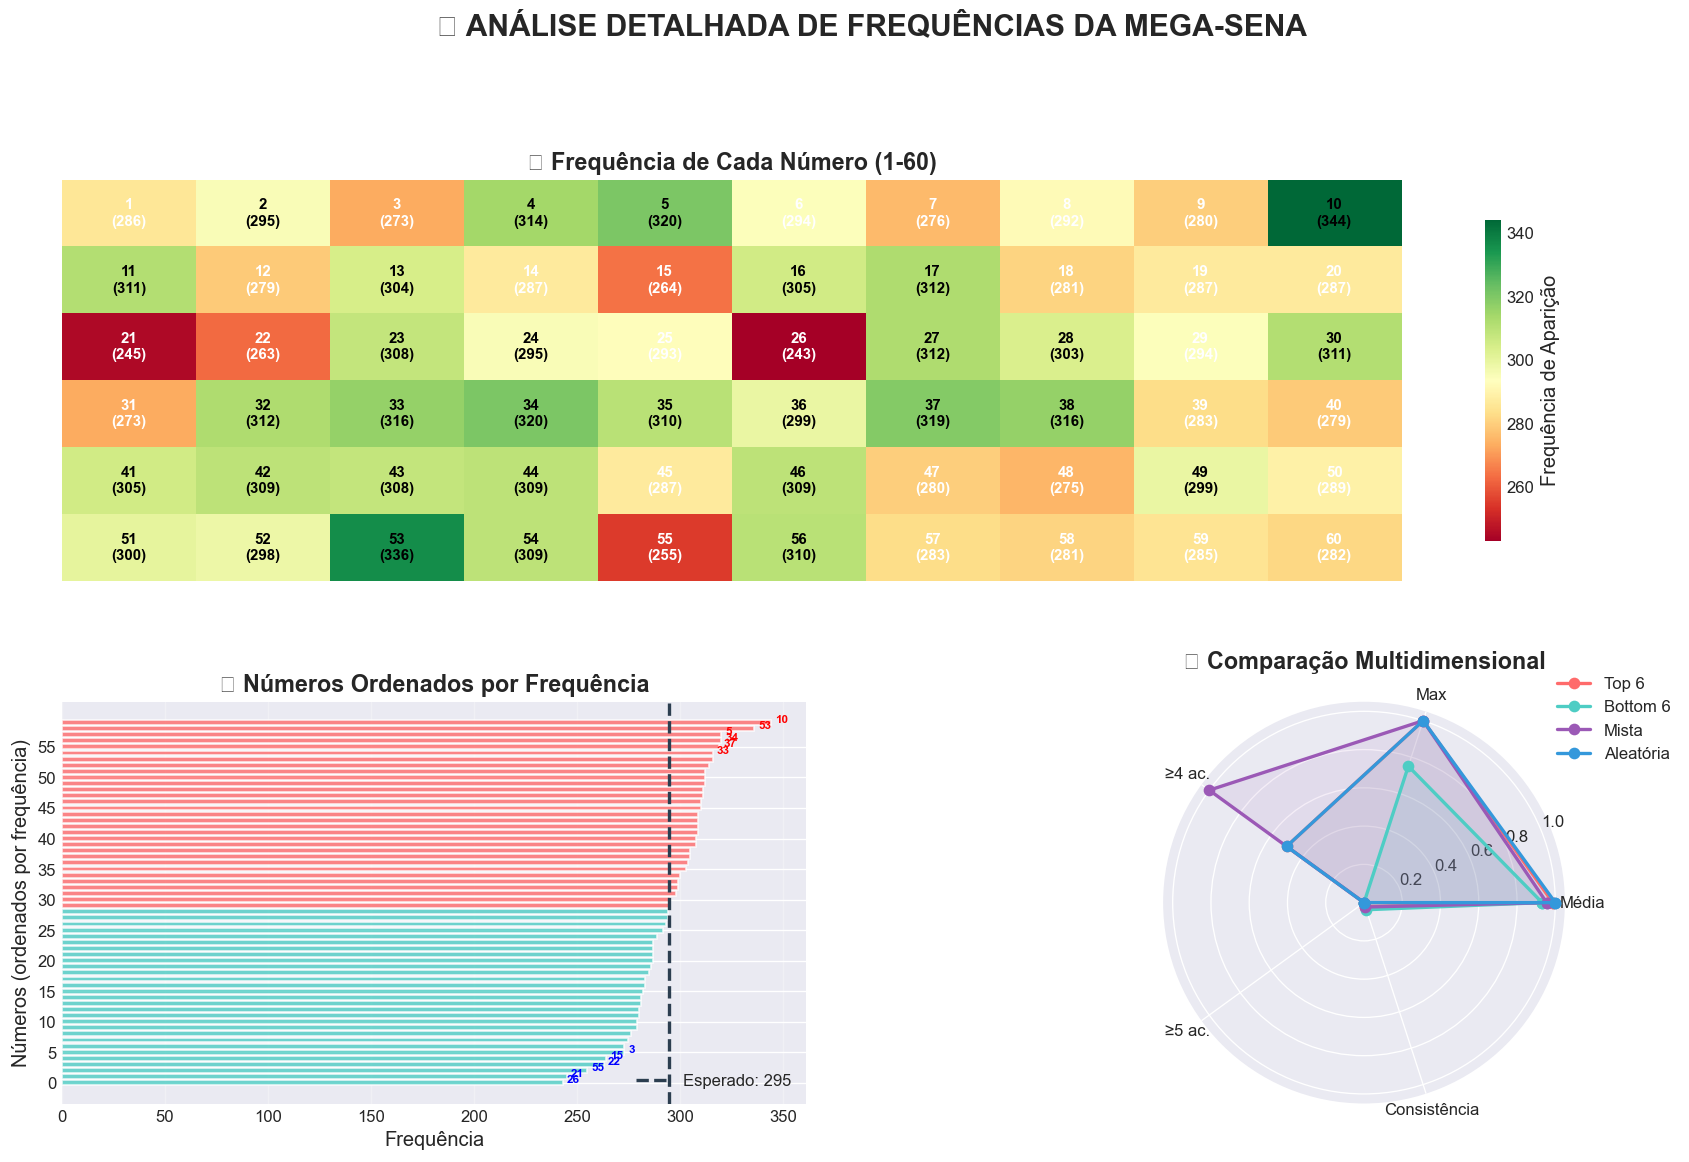


✅ Gráfico salvo como 'analise_frequencias_megasena.png'


In [12]:
# =============================================================================
# GRÁFICO 2 - HEATMAP DE FREQUÊNCIAS E ANÁLISE DETALHADA
# =============================================================================

fig2 = plt.figure(figsize=(18, 10))
fig2.suptitle('🔢 ANÁLISE DETALHADA DE FREQUÊNCIAS DA MEGA-SENA', 
              fontsize=18, fontweight='bold', y=1.02)

gs2 = GridSpec(2, 2, figure=fig2, hspace=0.3, wspace=0.25)

# =============================================================================
# Gráfico 1: Heatmap de frequência de todos os 60 números
# =============================================================================
ax1 = fig2.add_subplot(gs2[0, :])

# Reshape para 6x10
freq_matrix = frequencies.reshape(6, 10)

im = ax1.imshow(freq_matrix, cmap='RdYlGn', aspect='auto')
cbar = plt.colorbar(im, ax=ax1, shrink=0.8)
cbar.set_label('Frequência de Aparição', fontsize=12)

# Adicionar números e frequências nas células
for i in range(6):
    for j in range(10):
        num = i * 10 + j + 1
        freq = frequencies[num - 1]
        text_color = 'white' if freq < np.mean(frequencies) else 'black'
        ax1.text(j, i, f'{num}\n({freq})', ha='center', va='center', 
                fontsize=9, fontweight='bold', color=text_color)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('🎰 Frequência de Cada Número (1-60)', fontsize=14, fontweight='bold')

# =============================================================================
# Gráfico 2: Barras de todos os 60 números ordenados
# =============================================================================
ax2 = fig2.add_subplot(gs2[1, 0])

# Ordenar por frequência
sorted_indices_freq = np.argsort(frequencies)
sorted_freqs = frequencies[sorted_indices_freq]
sorted_nums = sorted_indices_freq + 1

# Colorir baseado em se está acima ou abaixo da média
colors_freq = ['#FF6B6B' if f >= expected_freq else '#4ECDC4' for f in sorted_freqs]

ax2.barh(range(60), sorted_freqs, color=colors_freq, alpha=0.8, edgecolor='white')
ax2.axvline(x=expected_freq, color='#2C3E50', linestyle='--', linewidth=2, 
            label=f'Esperado: {expected_freq:.0f}')

# Destacar top e bottom 6
for i, (num, freq) in enumerate(zip(sorted_nums, sorted_freqs)):
    if i < 6:  # Bottom 6
        ax2.annotate(f'{num}', (freq + 2, i), fontsize=7, fontweight='bold', color='blue')
    elif i >= 54:  # Top 6
        ax2.annotate(f'{num}', (freq + 2, i), fontsize=7, fontweight='bold', color='red')

ax2.set_xlabel('Frequência', fontsize=12)
ax2.set_ylabel('Números (ordenados por frequência)', fontsize=12)
ax2.set_title('📈 Números Ordenados por Frequência', fontsize=14, fontweight='bold')
ax2.set_yticks(range(0, 60, 5))
ax2.legend(loc='lower right')
ax2.grid(axis='x', alpha=0.3)

# =============================================================================
# Gráfico 3: Radar chart das estratégias
# =============================================================================
ax3 = fig2.add_subplot(gs2[1, 1], projection='polar')

metricas = ['Média', 'Max', '≥4 ac.', '≥5 ac.', 'Consistência']
n_metricas = len(metricas)

# Normalizar métricas (0-1)
valores_normalizados = {}

for est in estrategias:
    valores_normalizados[est] = [
        stats_resumo[est]['media'] / max([stats_resumo[e]['media'] for e in estrategias]),
        stats_resumo[est]['max'] / max([stats_resumo[e]['max'] for e in estrategias]),
        premios[est]['4 acertos'] / max([premios[e]['4 acertos'] for e in estrategias]) if max([premios[e]['4 acertos'] for e in estrategias]) > 0 else 0,
        premios[est]['5 acertos'] / max([premios[e]['5 acertos'] for e in estrategias]) if max([premios[e]['5 acertos'] for e in estrategias]) > 0 else 0,
        1 - (stats_resumo[est]['std'] / max([stats_resumo[e]['std'] for e in estrategias]))  # Menor std = maior consistência
    ]

angles = np.linspace(0, 2 * np.pi, n_metricas, endpoint=False).tolist()
angles += angles[:1]  # Fechar o círculo

for est, nome, cor in zip(estrategias, labels, colors_list):
    valores = valores_normalizados[est] + [valores_normalizados[est][0]]  # Fechar
    ax3.plot(angles, valores, 'o-', linewidth=2, label=nome, color=cor)
    ax3.fill(angles, valores, alpha=0.1, color=cor)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(metricas, fontsize=10)
ax3.set_title('🎯 Comparação Multidimensional', fontsize=14, fontweight='bold', pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('analise_frequencias_megasena.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Gráfico salvo como 'analise_frequencias_megasena.png'")

---
## 10. 📝 Resumo Final e Conclusões

In [13]:
print("="*80)
print("📊 RESUMO FINAL - ANÁLISE COMPARATIVA DE ESTRATÉGIAS")
print("="*80)

print(f"\n📌 DADOS ANALISADOS")
print(f"   • Total de concursos: {len(sorteios):,}")
print(f"   • Apostas simuladas: {N_SIMULATIONS:,}")
print(f"   • Período de simulação: Concurso {START_IDX+1} a {len(sorteios)}")

print(f"\n📐 VALOR TEÓRICO (ALEATÓRIO)")
print(f"   • Média esperada: {expected_value:.4f} acertos")
print(f"   • Desvio padrão: {theoretical_std:.4f}")

print(f"\n📊 COMPARAÇÃO DAS ESTRATÉGIAS")
print(f"   {'Estratégia':<15} {'Média':<10} {'Diff vs Teórico':<18} {'Status'}")
print("   " + "-"*60)

ranking = sorted(estrategias, key=lambda x: stats_resumo[x]['media'], reverse=True)

for i, est in enumerate(ranking):
    nome = {'top6': 'Top 6', 'bottom6': 'Bottom 6', 'mista': 'Mista', 'aleatoria': 'Aleatória'}[est]
    media = stats_resumo[est]['media']
    diff = distancia_aleatoriedade[est]['diff_perc']
    
    if abs(diff) < 1:
        status = "≈ Aleatório"
    elif diff > 0:
        status = "📈 Melhor"
    else:
        status = "📉 Pior"
    
    medal = ['🥇', '🥈', '🥉', ''][i]
    print(f"   {medal} {nome:<12} {media:<10.4f} {diff:+.2f}%{'':<12} {status}")

print(f"\n🏆 ACERTOS DE PRÊMIOS")
print(f"   {'Estratégia':<15} {'≥4 acertos':<12} {'≥5 acertos':<12} {'= 6 acertos'}")
print("   " + "-"*55)

for est in ranking:
    nome = {'top6': 'Top 6', 'bottom6': 'Bottom 6', 'mista': 'Mista', 'aleatoria': 'Aleatória'}[est]
    print(f"   {nome:<15} {premios[est]['4 acertos']:<12} {premios[est]['5 acertos']:<12} {premios[est]['6 acertos']}")

print(f"\n💡 CONCLUSÕES")
print("   " + "─"*70)

# Encontrar a melhor estratégia
melhor = ranking[0]
nome_melhor = {'top6': 'Top 6', 'bottom6': 'Bottom 6', 'mista': 'Mista', 'aleatoria': 'Aleatória'}[melhor]

print(f"\n   1. 📊 A estratégia com MELHOR desempenho foi: {nome_melhor}")
print(f"      (Média de {stats_resumo[melhor]['media']:.4f} acertos)")

print(f"\n   2. 📏 Todas as estratégias ficaram PRÓXIMAS do valor teórico ({expected_value:.4f})")
print(f"      Isso indica que a Mega-Sena é estatisticamente ALEATÓRIA.")

print(f"\n   3. 🎲 A diferença entre as estratégias é MARGINAL e dentro")
print(f"      da variância esperada para eventos aleatórios.")

print(f"\n   4. ⚠️ NENHUMA estratégia baseada em frequências históricas")
print(f"      oferece vantagem estatística significativa sobre apostar")
print(f"      números aleatórios.")

print(f"\n   5. 🎰 A Mega-Sena é um jogo de PURA SORTE. Cada número")
print(f"      tem a mesma probabilidade de ser sorteado (1/60 ≈ 1.67%).")

print("\n" + "="*80)
print("📊 FIM DA ANÁLISE")
print("="*80)

📊 RESUMO FINAL - ANÁLISE COMPARATIVA DE ESTRATÉGIAS

📌 DADOS ANALISADOS
   • Total de concursos: 2,949
   • Apostas simuladas: 2,849
   • Período de simulação: Concurso 101 a 2949

📐 VALOR TEÓRICO (ALEATÓRIO)
   • Média esperada: 0.6000 acertos
   • Desvio padrão: 0.7030

📊 COMPARAÇÃO DAS ESTRATÉGIAS
   Estratégia      Média      Diff vs Teórico    Status
   ------------------------------------------------------------
   🥇 Aleatória    0.6097     +1.61%             📈 Melhor
   🥈 Top 6        0.6020     +0.33%             ≈ Aleatório
   🥉 Mista        0.5823     -2.95%             📉 Pior
    Bottom 6     0.5679     -5.35%             📉 Pior

🏆 ACERTOS DE PRÊMIOS
   Estratégia      ≥4 acertos   ≥5 acertos   = 6 acertos
   -------------------------------------------------------
   Aleatória       1            0            0
   Top 6           1            0            0
   Mista           2            0            0
   Bottom 6        0            0            0

💡 CONCLUSÕES
   ─────────

In [14]:
# Exibir as imagens salvas
from IPython.display import Image, display

print("\n📊 VISUALIZAÇÕES GERADAS:")
print("   • analise_comparativa_megasena.png")
print("   • analise_frequencias_megasena.png")


📊 VISUALIZAÇÕES GERADAS:
   • analise_comparativa_megasena.png
   • analise_frequencias_megasena.png
